# M4-B2 — Vision PCB Defect (binôme async)

Auteurs : `Romain` version de travail — Date : `08/07/2026`

**Conventions** :
- `random_state=42`
- Pas de `print` excessif
- `Co-authored-by:` sur les commits significatifs

In [2]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import torch
from PIL import Image

sys.path.append('..')  # racine du repo → permet les imports « package » src.*
from src.load_data import CLASSES, get_dataloaders

DATA_DIR = Path('../data/pcb_defect_sample')
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device : {DEVICE}")

Device : cpu


In [5]:
# decision_helper.py — Python 3.11+, aucune dépendance externe
from dataclasses import dataclass

# Créez 3 instances Probleme correspondant à 3 variantes du cas TechniMatic :
#    le cas nominal (images PCB, ~280 labels/classe) ;
#    une variante « 0 donnée labellisée » (TechniMatic n'a encore rien étiqueté) ;
#    une variante « 50 000 images disponibles »
Probleme_nominal = Probleme("image", nb_labels_par_classe=280,
    classes_generiques=False, contrainte_latence_ms=100)
Probleme_zero_data = Probleme("image", nb_labels_par_classe=0,
    classes_generiques=False, contrainte_latence_ms=100)
Probleme_50k = Probleme("image", nb_labels_par_classe=50000,
    classes_generiques=False, contrainte_latence_ms=100)

@dataclass
class Probleme:
    type_donnees: str          # "tabulaire" | "image" | "texte"
    nb_labels_par_classe: int  # exemples labellisés disponibles par classe
    classes_generiques: bool   # les classes sont-elles "grand public" (chat, vélo) ?
    contrainte_latence_ms: int # budget d'inférence acceptable

def recommander(p: Probleme) -> str:
    if p.type_donnees == "tabulaire":
        return "ML classique (scikit-learn) — pas de deep learning."
    # données non structurées -> on entre dans le DL
    if p.nb_labels_par_classe == 0:
        if p.classes_generiques:
            return "Zero-shot (CLIP) — 0 donnée, MVP immédiat."
        return ("Zero-shot en test, MAIS classes spécifiques : précision "
                "probablement faible. Plan B : labelliser puis transfer.")
    if p.nb_labels_par_classe < 500:
        if p.contrainte_latence_ms < 30:
            return ("Transfer learning avec un backbone léger (ResNet-18) — "
                    "attention au budget latence, mesurez.")
        return "Transfer learning (ResNet/ViT) — meilleur compromis."
    return "From scratch envisageable, mais comparez d'abord au transfer."

if __name__ == "__main__":
    cas_pcb = Probleme("image", nb_labels_par_classe=280,
                       classes_generiques=False, contrainte_latence_ms=100)
    # Lancez recommander() sur les trois et notez ce qui change.
    print(recommander(Probleme_nominal))
    print(recommander(Probleme_zero_data))
    print(recommander(Probleme_50k))

    # Discutez en binôme : la sortie de la règle correspond-elle à votre intuition ? Sur quel critère hésitez-vous ?
    # Reportez la décision retenue (et la voie que vous implémenterez réellement) dans decisions.md, avec une condition de changement d'avis (concept 5).

Transfer learning (ResNet/ViT) — meilleur compromis.
Zero-shot en test, MAIS classes spécifiques : précision probablement faible. Plan B : labelliser puis transfer.
From scratch envisageable, mais comparez d'abord au transfer.


## 1. EDA dataset PCB (~1h binôme)

- Distribution des 7 classes (déséquilibre ?)
- Visualisation 7×3 subplot (3 exemples par classe)
- Notes : qualité d'image, variabilité intra-classe, ambiguïtés

In [11]:
# TODO — distribution des classes
from collections import Counter
# Dans DATA_DIR on parcours chaque dossier de classe et on compte le nombre d'images
for class_dir in DATA_DIR.iterdir():
    if class_dir.is_dir():
        num_images = len(list(class_dir.glob('*.png')))
        print(f"Classe {class_dir.name} : {num_images} images")
counts = Counter({class_dir.name: len(list(class_dir.glob('*.png'))) for class_dir in DATA_DIR.iterdir() if class_dir.is_dir()})

print("\n")
Total_images = sum(counts.values())
print(f"Total images : {Total_images}")
if Total_images != 2100:
    print("Attention : le nombre total d'images n'est pas égal à 2100.")
else:
    print("Le nombre total d'images est correct (2100).")

Classe copper : 300 images
Classe mousebite : 300 images
Classe ok : 300 images
Classe open : 300 images
Classe pin_hole : 300 images
Classe short : 300 images
Classe spur : 300 images


Total images : 2100
Le nombre total d'images est correct (2100).


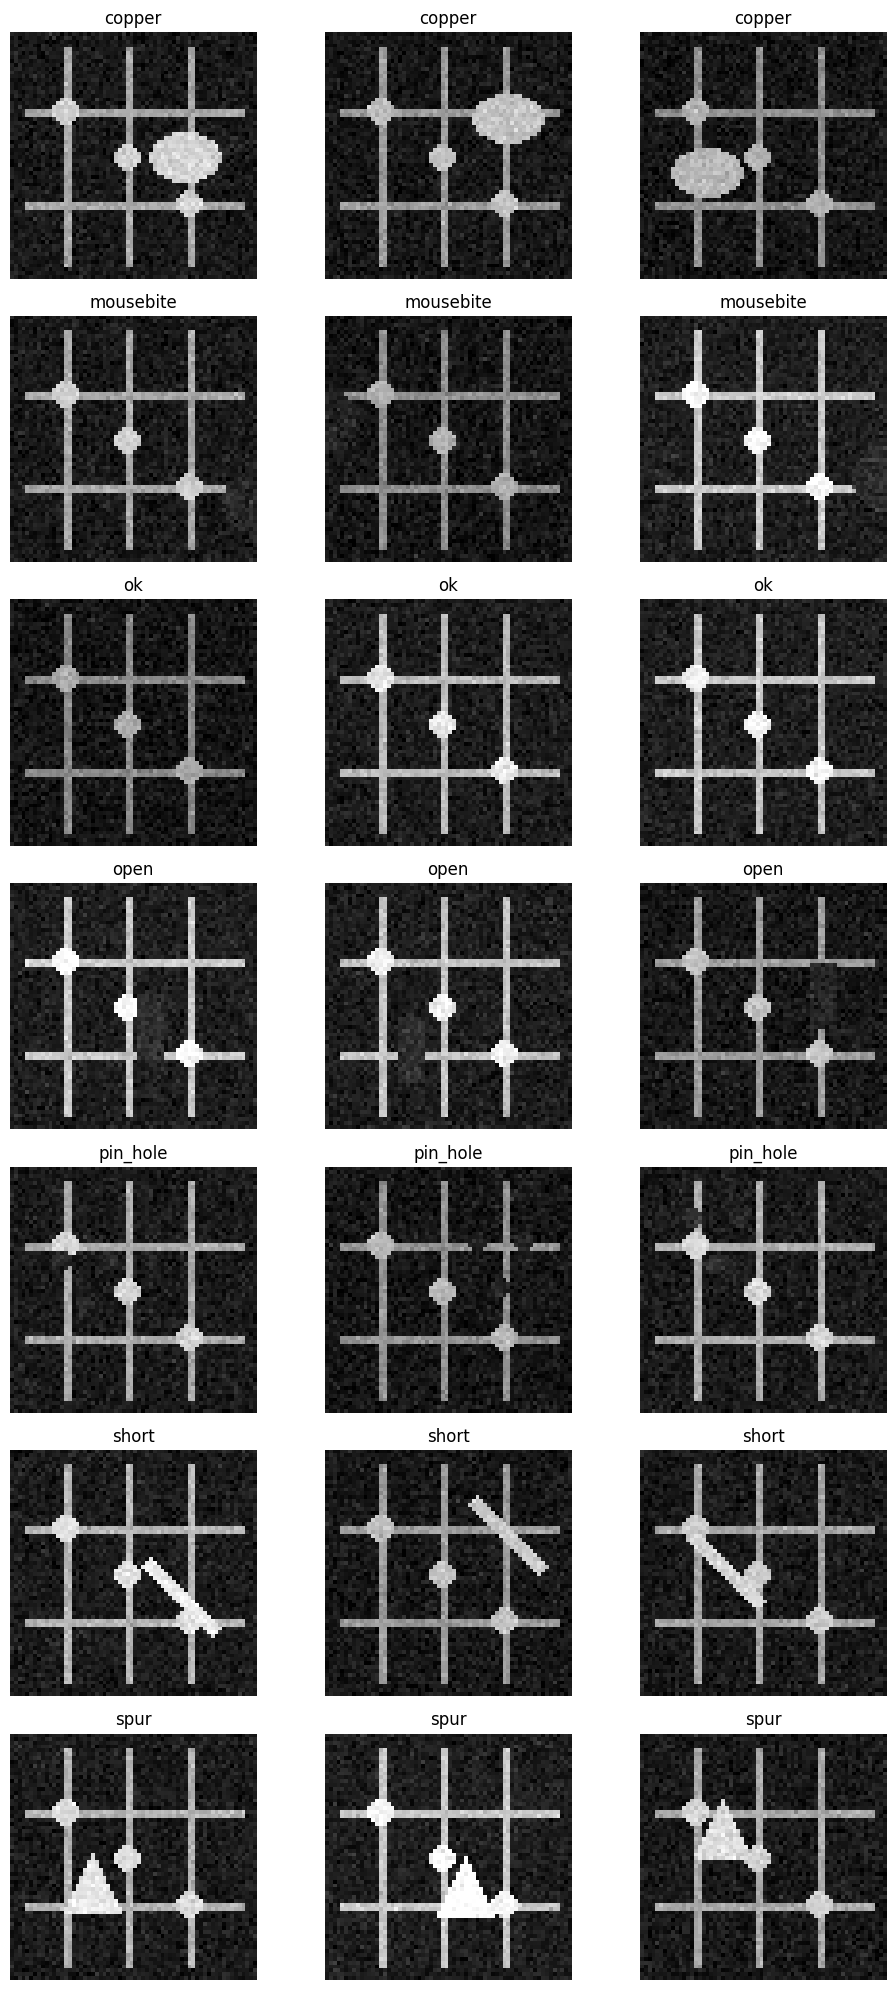

In [18]:
# TODO — 3 exemples par classe en grille 7×3
import matplotlib.pyplot as plt
from torch import random

# Affichage de 3 images par classe en grille 7x3
fig, axes = plt.subplots(nrows=7, ncols=3, figsize=(10, 20))
for i, (class_name, count) in enumerate(counts.items()):
    # On prend 3 images aléatoires de chaque classe
    all_image_paths = list((DATA_DIR / class_name).glob('*.png'))
    idx = torch.randperm(len(all_image_paths))[:3].tolist()
    image_paths = [all_image_paths[k] for k in idx]
    for j, image_path in enumerate(image_paths):
        # Conversion en RGB pour conserver les couleurs réelles des PNG (évite les faux colormaps)
        with Image.open(image_path) as img:
            axes[i, j].imshow(img.convert('RGB'))
        axes[i, j].set_title(class_name)
        axes[i, j].axis('off')

plt.tight_layout()
plt.show()

#### Analyse EDA

- **Distribution des classes** : dataset équilibré, avec **300 images par classe** (`copper`, `mousebite`, `ok`, `open`, `pin_hole`, `short`, `spur`), soit **2100 images** au total.

- **Qualité d'image** :
  - Images en niveaux de gris, contraste globalement bon entre pistes PCB et fond.
  - Présence d'un bruit visuel (granularité) assez constant.
  - Résolution suffisante pour distinguer les défauts principaux, mais certains défauts peuvent rester peu visible.

C'est un dataset synthétique : ce sont des images simples générées de façon artificielle :)

- **Variabilité intra-classe** :
  - Variabilité **faible** sur la géométrie des pistes (structure très répétitive).
  - Variabilité visible surtout sur la **position**, la **taille** et parfois l'orientation locale du défaut.
  - La classe `ok` semble la plus homogène ; `copper`, `open`, `short` et `spur` montrent un peu plus de diversité de formes.

- **Ambiguïtés potentielles** :
  - Attention aux défauts de petite taille (`mousebite`, `pin_hole`) et aux images proches de `ok`.
  - Risque de confusion entre les défauts affectant la continuité des pistes (`open` vs certains cas de `mousebite` selon la zone observée).
  - Les motifs répétitifs du PCB peuvent masquer des défauts subtils si le modèle ne capte pas bien les détails locaux notamment sur `mousebite` très proche de `ok`.

- **Implication pour la suite** :
  - Le dataset équilibré est favorable à l'entraînement.
  - Il faudra surveiller la matrice de confusion sur les paires ambiguës et privilégier une approche robuste aux détails fins (augmentation légère + transfert learning).

## 2. Implémentation de l'option choisie (~4h binôme)

Cf. `decisions.md` pour le choix (A / B / C).

- Option A : `src/option_a_cnn.py` => Romain
- Option B : `src/option_b_transfer.py` => Théo
- Option C : `src/option_c_clip.py`

In [ ]:
# TODO — entraîner ou inférer l'option choisie
# Import : from src.option_a_cnn import SimpleCNN, train_one_epoch, evaluate  (idem b/c)
# Mesure : temps train (si options A ou B), latence inférence (toutes options), accuracy
from src.option_a_cnn import SimpleCNN, train_one_epoch, evaluate
# TODO

## 3. Comparaison économique 3 approches (~1h30)

Voir `economic_comparison.md` à remplir.

## 4. Verdict + préparation restitution duo (~1h30)

- `verdict.md` : recommandation, 8 lignes max
- Préparation restitution mardi 1ᵉʳ sept (rentrée M5) : qui dit quoi ?